<h1 style="color:pink;">Entrenamiento de CNN con modificaciones en su función de pérdida.</h1>
<p> Valentina Arce España <p>
<p> Febrero 24, 2026 <p>

Aquí entreno con la función $L_{total} = L_{MSE} + \lambda_1 L_{NASA} + \lambda_2 \frac{1}{m-1}\sum dh^2$ usando las operaciones matemáticas de PyTorch.

In [1]:
import sys
print(sys.executable)

/Users/mac/Documents/Tendencias/torch-env/bin/python


In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

filename = 'N-CMAPSS_DS08a-009.h5' 
WINDOW_SIZE = 50   
BATCH_SIZE = 512
EPOCHS = 15

# --- PARÁMETROS DE REDUCCIÓN ---
# Usar solo el 30% de los motores disponibles para entrenar (0.1 = 10%, 1.0 = 100%)
TRAIN_RATIO = 0.3  

# Salto al crear ventanas (Downsampling). 
# 1 = toma todas las ventanas posibles (máxima memoria).
# 10 = toma 1 ventana cada 10 segundos. Reduce el tamaño del dataset en 10x.
WINDOW_STEP = 10  

def load_data(filepath):
    with h5py.File(filepath, 'r') as hdf:
        # Development set (Train)
        W_dev = np.array(hdf.get('W_dev'))
        X_s_dev = np.array(hdf.get('X_s_dev'))
        X_v_dev = np.array(hdf.get('X_v_dev'))
        Y_dev = np.array(hdf.get('Y_dev'))
        A_dev = np.array(hdf.get('A_dev')) 
        
        # Test set
        W_test = np.array(hdf.get('W_test'))
        X_s_test = np.array(hdf.get('X_s_test'))
        X_v_test = np.array(hdf.get('X_v_test'))
        Y_test = np.array(hdf.get('Y_test'))
        A_test = np.array(hdf.get('A_test'))
        
        # Corrección de lectura de variables
        A_var = np.array(hdf.get('A_var'))
        A_var = list(np.array(A_var, dtype='U20'))
        
    return (W_dev, X_s_dev, X_v_dev, Y_dev, A_dev), (W_test, X_s_test, X_v_test, Y_test, A_test), A_var

print("Cargando datos...")
(train_W, train_Xs, train_Xv, train_Y, train_A), \
(test_W, test_Xs, test_Xv, test_Y, test_A), A_var = load_data(filename)

# Identificar unidades únicas en entrenamiento
train_units = np.unique(train_A[:, 0])
n_units_original = len(train_units)
n_units_keep = int(n_units_original * TRAIN_RATIO)

# Seleccionar solo las primeras N unidades
keep_units = train_units[:n_units_keep]

print(f"Reduciendo dataset de entrenamiento: Usando {n_units_keep} de {n_units_original} motores.")

# Filtrar los arrays de entrenamiento
# Buscamos los índices donde la columna unit (0) esté en nuestra lista keep_units
mask_train = np.isin(train_A[:, 0], keep_units)

train_W = train_W[mask_train]
train_Xs = train_Xs[mask_train]
train_Xv = train_Xv[mask_train]
train_Y = train_Y[mask_train]
train_A = train_A[mask_train]


X_train = np.concatenate((train_W, train_Xs, train_Xv), axis=1)
X_test = np.concatenate((test_W, test_Xs, test_Xv), axis=1)

scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Forma de X_train (reducido): {X_train_scaled.shape}")


def create_windows(X, y, A, window_size, step=1, unit_col_index=0):
    unique_units = np.unique(A[:, unit_col_index])
    X_windows = []
    y_windows = []
    
    for unit in unique_units:
        idx = np.where(A[:, unit_col_index] == unit)[0]
        unit_X = X[idx, :]
        unit_y = y[idx]
        
        num_samples = len(unit_X)
        if num_samples < window_size:
            continue
            
        # APLICAMOS EL STEP AQUÍ PARA REDUCIR DATOS
        for i in range(0, num_samples - window_size + 1, step):
            X_windows.append(unit_X[i : i + window_size, :])
            y_windows.append(unit_y[i + window_size - 1])
            
    return np.array(X_windows), np.array(y_windows)

print(f"Generando ventanas (Step={WINDOW_STEP})...")
# Entrenamos con salto para ahorrar memoria
X_train_w, y_train_w = create_windows(X_train_scaled, train_Y, train_A, WINDOW_SIZE, step=WINDOW_STEP)

# Para test, generalmente queremos evaluar todo, pero si falla memoria, aumenta el step aquí también
X_test_w, y_test_w = create_windows(X_test_scaled, test_Y, test_A, WINDOW_SIZE, step=10) 

print(f"Input Shape Train Final: {X_train_w.shape}")
print(f"Input Shape Test Final: {X_test_w.shape}")

Cargando datos...
Reduciendo dataset de entrenamiento: Usando 2 de 9 motores.
Forma de X_train (reducido): (1060535, 32)
Generando ventanas (Step=10)...
Input Shape Train Final: (106045, 50, 32)
Input Shape Test Final: (372274, 50, 32)


In [3]:
import torch
import torch.nn as nn

class PhysicsInformedRULLoss(nn.Module):
    def __init__(self, lambda1=0.1, lambda2=0.5):
        super(PhysicsInformedRULLoss, self).__init__()
        self.mse = nn.MSELoss()
        self.lambda1 = lambda1
        self.lambda2 = lambda2

    def forward(self, y_pred, y_true):
        # 1. Error Base (MSE)
        loss_mse = self.mse(y_pred, y_true)
        
        # 2. NASA Scoring Function
        # d = pred - real. Asimétrica: castiga más la sobreestimación del RUL
        d = y_pred - y_true
        nasa_loss = torch.where(d < 0, 
                                torch.exp(-d / 13.0) - 1, 
                                torch.exp(d / 10.0) - 1)
        loss_nasa = torch.mean(nasa_loss)
        
        # 3. Regularización de Suavidad Temporal (dh^2)
        # Calculamos la diferencia entre la predicción actual y la del instante anterior (dentro del mismo batch)
        if y_pred.shape[0] > 1:
            dh = y_pred[1:] - y_pred[:-1] # dh = h[2:end] - h[1:end-1]
            loss_dh2 = torch.mean(dh ** 2)
        else:
            loss_dh2 = torch.tensor(0.0, device=y_pred.device)
            
        # Pérdida Total
        loss_total = loss_mse + (self.lambda1 * loss_nasa) + (self.lambda2 * loss_dh2)
        
        return loss_total

In [4]:
from torch.utils.data import TensorDataset, DataLoader

# Asumiendo que X_train y y_train ya son arrays de numpy con forma (106045, 50, 32)
# Convertimos los datos a tensores de PyTorch
X_tensor = torch.tensor(X_train_w, dtype=torch.float32)
y_tensor = torch.tensor(y_train_w, dtype=torch.float32).view(-1, 1) # Asegurar forma (batch, 1)

# Crear dataset y dataloader
train_dataset = TensorDataset(X_tensor, y_tensor)

# ¡shuffle=False es obligatorio para la regularización temporal!
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=False)

In [5]:
class CNN_RUL(nn.Module):
    def __init__(self, num_features=32, window_size=50):
        super(CNN_RUL, self).__init__()
        
        # Las capas convolucionales
        self.conv1 = nn.Conv1d(in_channels=num_features, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv1d(in_channels=128, out_channels=64, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(in_channels=64, out_channels=32, kernel_size=3, padding=1)
        
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        
        # Calcular el tamaño aplanado: 32 canales de salida * tamaño de ventana 50 = 1600
        self.fc1 = nn.Linear(32 * window_size, 128)
        self.fc2 = nn.Linear(128, 1) # Predicción final del RUL

    def forward(self, x):
        # Transponer de (Batch, 50, 32) a (Batch, 32, 50) para PyTorch
        x = x.permute(0, 2, 1) 
        
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.relu(self.conv5(x))
        
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_RUL().to(device)
criterion = PhysicsInformedRULLoss(lambda1=0.1, lambda2=0.5) # Aquí afinarás los pesos
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 15

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        # 1. Limpiar gradientes
        optimizer.zero_grad()
        
        # 2. Forward pass (predecir)
        outputs = model(inputs)
        
        # 3. Calcular la pérdida
        loss = criterion(outputs, targets)
        
        # 4. Backward pass (retropropagación)
        loss.backward()
        
        # Opcional pero recomendado para la función NASA: Limitar gradientes si explotan
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # 5. Actualizar pesos
        optimizer.step()
        
        running_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/15, Loss: 453.8735
Epoch 2/15, Loss: 443420.5924
Epoch 3/15, Loss: 425.7364
Epoch 4/15, Loss: 398.2806
Epoch 5/15, Loss: 442.6282
Epoch 6/15, Loss: 483.9646
Epoch 7/15, Loss: 479.7382
Epoch 8/15, Loss: 639.9754
Epoch 9/15, Loss: 465.0916
Epoch 10/15, Loss: 535.5023
Epoch 11/15, Loss: 509.2284
Epoch 12/15, Loss: 485.0057
Epoch 13/15, Loss: 537.9828
Epoch 14/15, Loss: 401.9061
Epoch 15/15, Loss: 541.9392


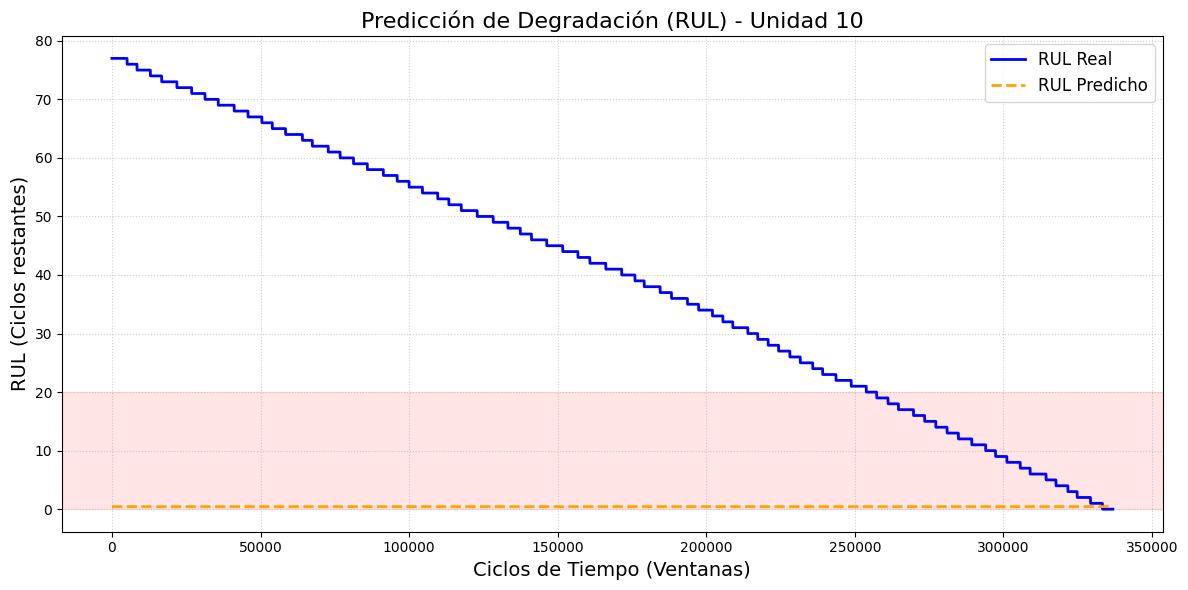

In [7]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import torch

def comparar_resultados_motores(unit_id):
    # 1. Filtrar los datos crudos de test para el motor específico
    idx = np.where(test_A[:, 0] == unit_id)[0]
    
    if len(idx) == 0:
        print(f"No se encontraron datos en el conjunto de prueba para el motor {unit_id}")
        return
        
    unit_X = X_test_scaled[idx, :]
    unit_y = test_Y[idx]
    unit_A = test_A[idx, :]
    
    # 2. Crear las ventanas temporales para este motor
    X_motor_w, y_motor_w = create_windows(unit_X, unit_y, unit_A, WINDOW_SIZE, step=1)
    
    # --- LA SOLUCIÓN AL KERNEL CRASH ---
    # Envolver los datos de prueba en un DataLoader para predecir por lotes
    X_tensor_motor = torch.tensor(X_motor_w, dtype=torch.float32)
    test_dataset = TensorDataset(X_tensor_motor)
    
    # Usamos un batch_size grande (ej. 512 o 1024) ya que la inferencia no requiere gradientes
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)
    
    # 3. Inferencia con PyTorch
    model.eval() 
    y_pred_list = [] # Lista para guardar las predicciones de cada lote
    
    with torch.no_grad():
        for batch in test_loader:
            inputs = batch[0].to(device)
            # Predecir el lote actual
            outputs = model(inputs)
            # Guardar el resultado en la lista
            y_pred_list.append(outputs.cpu().numpy())
            
    # Concatenar todos los lotes en un solo arreglo final
    y_pred = np.concatenate(y_pred_list, axis=0)
        
    # 4. Generar la gráfica
    plt.figure(figsize=(12, 6))
    
    plt.plot(y_motor_w, label='RUL Real', color='blue', linewidth=2)
    plt.plot(y_pred, label='RUL Predicho', color='orange', linestyle='--', linewidth=2)
    
    plt.title(f'Predicción de Degradación (RUL) - Unidad {unit_id}', fontsize=16)
    plt.xlabel('Ciclos de Tiempo (Ventanas)', fontsize=14)
    plt.ylabel('RUL (Ciclos restantes)', fontsize=14)
    plt.legend(loc='upper right', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.axhspan(0, 20, color='red', alpha=0.1, label='Zona Crítica')
    
    plt.tight_layout()
    plt.show()

# --- Ejecutar la prueba con el motor 10 ---
comparar_resultados_motores(10)

# The three bugs and their fixes
## Bug 1 — Cross-engine dh contamination (the main culprit)

Your `dh = y_pred[1:] - y_pred[:-1]` computes differences between all consecutive predictions in the batch. But with `shuffle=False`, the dataset is laid out as: all windows from Engine 1, then all windows from Engine 2. At the boundary, `y_pred[last_of_engine1]` and `y_pred[first_of_engine2]` are treated as temporally adjacent — which is physically nonsense and injects a large, random gradient into your smoothness term.

The fix is `same_unit_mask = (unit_ids[1:] == unit_ids[:-1])`. Only the dh values where both predictions come from the same engine are included. This required adding `unit_id` as a third return value from `create_windows` and passing it through the DataLoader.

## Bug 2 — Scale mismatch between loss terms (the reason results were "inconclusive")

MSE on raw RUL cycles can be in the thousands. The NASA term outputs values of order 1–10. The dh² term depends on prediction volatility and can be anywhere. With `lambda2=0.5` chosen blindly, you were almost certainly letting one term completely dominate. The new diagnostic block (Cell 7) runs a single batch with `lambda1=lambda2=1.0` and prints the raw magnitudes, then suggests starting values that put the three terms on equal footing.

## Bug 3 — Minor: unit_ids must be cast to .long() inside the training loop

`TensorDataset` doesn't accept int tensors directly, so they're stored as `float`. They need to be cast back to `.long()` (integer) before the boolean comparison `unit_ids[1:] == unit_ids[:-1]` works correctly. The loop now does `uid = uid.long().to(device).`